# M7 — Convolutional Autoencoder Baseline

This notebook trains and evaluates a convolutional autoencoder for anomaly detection in DeepSeti.

## Training rule

The autoencoder is trained **only on normal real radio spectrogram frames from the training split**.

Synthetic technosignatures are never used for training.

## Goal

Learn to reconstruct normal radio spectrograms and test whether synthetic technosignature-like signals produce larger reconstruction errors.

## Comparison

We will compare this model against the PCA reconstruction baseline before moving to ViT-MAE.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [ ]:
# --########
from deepseti.injection.dataset import load_split_frame_pool
from deepseti.preprocessing.frames import normalize_frames

raw_train, train_metadata = load_split_frame_pool(
    manifest_path="../configs/data/observations.csv",
    raw_root="../data/raw",
    split="train",
    f_start=2200,
    f_stop=2300,
)

train_frames = normalize_frames(raw_train)

print("Training frames:", train_frames.shape)
print(
    "Training observations:",
    len({m["observation_id"] for m in train_metadata}),
)
print("All finite:", np.isfinite(train_frames).all())

/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Training frames: (816, 16, 4096)
Training observations: 6
All finite: True


In [4]:
train_tensor = torch.from_numpy(
    train_frames
).float().unsqueeze(1)

train_dataset = TensorDataset(
    train_tensor,
    train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
)

print("Tensor shape:", train_tensor.shape)
print("Number of batches:", len(train_loader))

Tensor shape: torch.Size([816, 1, 16, 4096])
Number of batches: 51


1 × 16 × 4096
↓
8 × 8 × 2048
↓
16 × 4 × 1024
↓
32 × 2 × 512
↓
64 × 1 × 256
↓
decoder
↓
1 × 16 × 4096

In [5]:
from deepseti.models.conv_autoencoder import ConvAutoencoder

conv_ae = ConvAutoencoder().to(device)

sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    reconstructed = conv_ae(sample_batch)

print("Input shape:", sample_batch.shape)
print("Reconstructed shape:", reconstructed.shape)
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in conv_ae.parameters()
        if p.requires_grad
    ),
)

Input shape: torch.Size([16, 1, 16, 4096])
Reconstructed shape: torch.Size([16, 1, 16, 4096])
Trainable parameters: 67577


In [6]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    conv_ae.parameters(),
    lr=1e-3,
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: MSELoss()
Optimizer: Adam


In [8]:
from tqdm.auto import tqdm

num_epochs = 20
train_losses = []

epoch_bar = tqdm(
    range(1, num_epochs + 1),
    desc="Training ConvAE",
)

for epoch in epoch_bar:

    conv_ae.train()

    running_loss = 0.0

    batch_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{num_epochs}",
        leave=False,
    )

    for inputs, _ in batch_bar:

        inputs = inputs.to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        reconstructed = conv_ae(inputs)

        loss = criterion(
            reconstructed,
            inputs,
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * inputs.size(0)
        )

        batch_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss
        / len(train_loader.dataset)
    )

    train_losses.append(
        epoch_loss
    )

    epoch_bar.set_postfix(
        epoch_loss=f"{epoch_loss:.4f}"
    )

print("Training complete.")
print("Final training loss:", train_losses[-1])

/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Training ConvAE: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s, epoch_loss=0.3825]

Training complete.
Final training loss: 0.38251201691580755


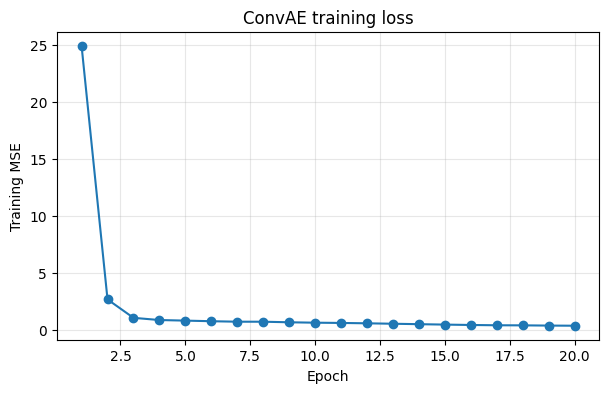

First epoch loss: 24.915558917849673
Final epoch loss: 0.38251201691580755


In [9]:
%matplotlib inline

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("ConvAE training loss")

plt.grid(alpha=0.3)
plt.show()

print("First epoch loss:", train_losses[0])
print("Final epoch loss:", train_losses[-1])

In [10]:
validation_clean = np.load(
    "../data/synthetic/validation/clean_frames.npy"
)

validation_injected = np.load(
    "../data/synthetic/validation/injected_frames.npy"
)

with open(
    "../data/synthetic/validation/metadata.json"
) as f:
    validation_metadata = json.load(f)

print("Clean:", validation_clean.shape)
print("Injected:", validation_injected.shape)
print("Metadata:", len(validation_metadata))

Clean: (700, 16, 4096)
Injected: (700, 16, 4096)
Metadata: 700


In [11]:
def conv_ae_scores(
    model,
    frames,
    batch_size=32,
):
    model.eval()

    scores = []

    for start in tqdm(
        range(0, len(frames), batch_size),
        desc="Scoring",
    ):
        batch = torch.from_numpy(
            frames[start:start + batch_size]
        ).float().unsqueeze(1).to(device)

        with torch.no_grad():
            reconstructed = model(batch)

            squared_error = (
                batch - reconstructed
            ) ** 2

            batch_scores = squared_error.mean(
                dim=(1, 2, 3)
            )

        scores.extend(
            batch_scores.cpu().numpy()
        )

    return np.asarray(scores)


clean_scores = conv_ae_scores(
    conv_ae,
    validation_clean,
)

injected_scores = conv_ae_scores(
    conv_ae,
    validation_injected,
)


labels = np.concatenate([
    np.zeros(len(clean_scores)),
    np.ones(len(injected_scores)),
])

scores = np.concatenate([
    clean_scores,
    injected_scores,
])


validation_auroc = roc_auc_score(
    labels,
    scores,
)

validation_auprc = average_precision_score(
    labels,
    scores,
)


print("Mean clean score:", clean_scores.mean())
print("Mean injected score:", injected_scores.mean())
print("Validation AUROC:", validation_auroc)
print("Validation AUPRC:", validation_auprc)

Scoring: 100%|██████████| 22/22 [00:00<00:00, 96.05it/s]

Mean clean score: 0.45367527
Mean injected score: 0.48110622
Validation AUROC: 0.5438183673469388
Validation AUPRC: 0.5353164256906746


In [12]:
def conv_ae_top_fraction_scores(
    model,
    frames,
    fraction=0.002,
    batch_size=32,
):
    model.eval()

    scores = []

    for start in tqdm(
        range(0, len(frames), batch_size),
        desc="Scoring local errors",
    ):
        batch = torch.from_numpy(
            frames[start:start + batch_size]
        ).float().unsqueeze(1).to(device)

        with torch.no_grad():
            reconstructed = model(batch)

            squared_error = (
                batch - reconstructed
            ) ** 2

            flattened_error = squared_error.flatten(
                start_dim=1
            )

            k = max(
                1,
                int(flattened_error.shape[1] * fraction),
            )

            top_errors = torch.topk(
                flattened_error,
                k=k,
                dim=1,
            ).values

            batch_scores = top_errors.mean(dim=1)

        scores.extend(
            batch_scores.cpu().numpy()
        )

    return np.asarray(scores)


clean_top_scores = conv_ae_top_fraction_scores(
    conv_ae,
    validation_clean,
    fraction=0.002,
)

injected_top_scores = conv_ae_top_fraction_scores(
    conv_ae,
    validation_injected,
    fraction=0.002,
)

top_scores = np.concatenate([
    clean_top_scores,
    injected_top_scores,
])

top_auroc = roc_auc_score(
    labels,
    top_scores,
)

top_auprc = average_precision_score(
    labels,
    top_scores,
)

print("Whole-frame AUROC:", validation_auroc)
print("Top 0.2% AUROC:", top_auroc)

print("Whole-frame AUPRC:", validation_auprc)
print("Top 0.2% AUPRC:", top_auprc)

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 78.49it/s]

Whole-frame AUROC: 0.5438183673469388
Top 0.2% AUROC: 0.6042214285714286
Whole-frame AUPRC: 0.5353164256906746
Top 0.2% AUPRC: 0.5572510010683788


In [13]:
fraction_options = [
    0.00025,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
]

conv_fraction_results = []

for fraction in fraction_options:

    clean_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae,
        validation_clean,
        fraction=fraction,
    )

    injected_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae,
        validation_injected,
        fraction=fraction,
    )

    combined_scores = np.concatenate([
        clean_fraction_scores,
        injected_fraction_scores,
    ])

    auroc = roc_auc_score(
        labels,
        combined_scores,
    )

    auprc = average_precision_score(
        labels,
        combined_scores,
    )

    pixels = int(
        validation_clean.shape[1]
        * validation_clean.shape[2]
        * fraction
    )

    conv_fraction_results.append({
        "fraction": fraction,
        "pixels": pixels,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"fraction={fraction:.5f} "
        f"(~{pixels:4d} pixels) | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 77.39it/s]


fraction=0.00025 (~  16 pixels) | AUROC=0.5959 | AUPRC=0.5486


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 85.81it/s]


fraction=0.00050 (~  32 pixels) | AUROC=0.6010 | AUPRC=0.5527


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 85.90it/s]


...

fraction=0.00200 (~ 131 pixels) | AUROC=0.6042 | AUPRC=0.5573


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 84.77it/s]


fraction=0.00500 (~ 327 pixels) | AUROC=0.6012 | AUPRC=0.5601


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 84.25it/s]

fraction=0.01000 (~ 655 pixels) | AUROC=0.5966 | AUPRC=0.5600


In [14]:
for fraction in [0.00025, 0.0005]:

    clean_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae,
        validation_clean,
        fraction=fraction,
    )

    injected_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae,
        validation_injected,
        fraction=fraction,
    )

    combined_scores = np.concatenate([
        clean_fraction_scores,
        injected_fraction_scores,
    ])

    auroc = roc_auc_score(
        labels,
        combined_scores,
    )

    auprc = average_precision_score(
        labels,
        combined_scores,
    )

    pixels = int(
        validation_clean.shape[1]
        * validation_clean.shape[2]
        * fraction
    )

    print(
        f"fraction={fraction:.5f} "
        f"(~{pixels:4d} pixels) | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 80.32it/s]


fraction=0.00025 (~  16 pixels) | AUROC=0.5959 | AUPRC=0.5486


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 85.15it/s]

fraction=0.00050 (~  32 pixels) | AUROC=0.6010 | AUPRC=0.5527


In [15]:
best_conv_fraction = 0.001

print("Selected ConvAE top-error fraction:", best_conv_fraction)
print("Approx. pixels used:", 65)
print("Validation AUROC:", 0.6049)
print("Validation AUPRC:", 0.5555)

Selected ConvAE top-error fraction: 0.001
Approx. pixels used: 65
Validation AUROC: 0.6049
Validation AUPRC: 0.5555


In [ ]:
## ------
raw_val, val_metadata = load_split_frame_pool(
    manifest_path="../configs/data/observations.csv",
    raw_root="../data/raw",
    split="validation",
    f_start=2200,
    f_stop=2300,
)

val_frames = normalize_frames(raw_val)

val_tensor = torch.from_numpy(
    val_frames
).float().unsqueeze(1)

val_dataset = TensorDataset(
    val_tensor,
    val_tensor,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
)

print("Validation frames:", val_tensor.shape)
print(
    "Validation observations:",
    len({m["observation_id"] for m in val_metadata}),
)

Validation frames: torch.Size([272, 1, 16, 4096])
Validation observations: 2


In [21]:
import importlib
import deepseti.models.conv_autoencoder as conv_module

importlib.reload(conv_module)

print(
    "Has ConvAutoencoderV2:",
    hasattr(conv_module, "ConvAutoencoderV2"),
)

Has ConvAutoencoderV2: True


In [22]:
ConvAutoencoderV2 = conv_module.ConvAutoencoderV2

In [23]:
from deepseti.models.conv_autoencoder import ConvAutoencoderV2

torch.manual_seed(42)

conv_ae_v2 = ConvAutoencoderV2().to(device)

criterion_v2 = nn.MSELoss()

optimizer_v2 = torch.optim.Adam(
    conv_ae_v2.parameters(),
    lr=3e-4,
    weight_decay=1e-5,
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in conv_ae_v2.parameters()
        if p.requires_grad
    ),
)

print("Learning rate:", optimizer_v2.param_groups[0]["lr"])
print("Weight decay:", optimizer_v2.param_groups[0]["weight_decay"])

Trainable parameters: 269553
Learning rate: 0.0003
Weight decay: 1e-05


In [24]:
import copy

max_epochs = 40
patience = 5

train_losses_v2 = []
val_losses_v2 = []

best_val_loss = float("inf")
best_epoch = 0
best_state = None
epochs_without_improvement = 0

epoch_bar = tqdm(
    range(1, max_epochs + 1),
    desc="Training ConvAE V2",
)

for epoch in epoch_bar:

    # -------------------
    # Training
    # -------------------
    conv_ae_v2.train()

    train_running_loss = 0.0

    for inputs, _ in train_loader:

        inputs = inputs.to(device)

        optimizer_v2.zero_grad(
            set_to_none=True
        )

        reconstructed = conv_ae_v2(inputs)

        loss = criterion_v2(
            reconstructed,
            inputs,
        )

        loss.backward()
        optimizer_v2.step()

        train_running_loss += (
            loss.item()
            * inputs.size(0)
        )

    train_loss = (
        train_running_loss
        / len(train_loader.dataset)
    )

    # -------------------
    # Validation
    # -------------------
    conv_ae_v2.eval()

    val_running_loss = 0.0

    with torch.no_grad():

        for inputs, _ in val_loader:

            inputs = inputs.to(device)

            reconstructed = conv_ae_v2(inputs)

            loss = criterion_v2(
                reconstructed,
                inputs,
            )

            val_running_loss += (
                loss.item()
                * inputs.size(0)
            )

    val_loss = (
        val_running_loss
        / len(val_loader.dataset)
    )

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)

    # -------------------
    # Early stopping
    # -------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch

        best_state = copy.deepcopy(
            conv_ae_v2.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_val_loss:.4f}",
    )

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}."
        )
        break


# Restore the best validation checkpoint
conv_ae_v2.load_state_dict(
    best_state
)

print("Training complete.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Training ConvAE V2: 100%|██████████| 40/40 [01:06<00:00,  1.66s/it, best=0.3459, train=0.3057, val=0.3459]

Training complete.
Best epoch: 40
Best validation loss: 0.34587790334925933


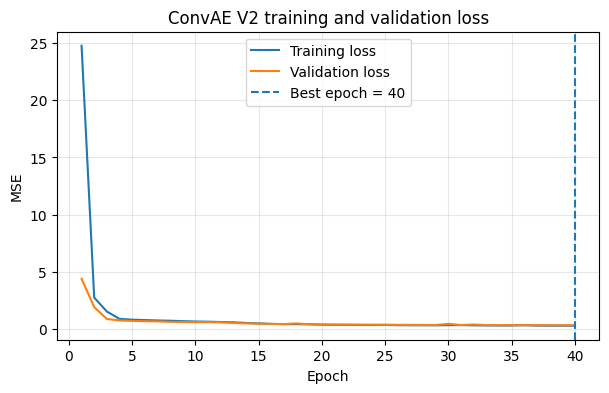

Final training loss: 0.30574484111047256
Final validation loss: 0.34587790334925933


In [25]:
epochs_ran = range(
    1,
    len(train_losses_v2) + 1,
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs_ran,
    train_losses_v2,
    label="Training loss",
)

plt.plot(
    epochs_ran,
    val_losses_v2,
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("ConvAE V2 training and validation loss")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Final training loss:", train_losses_v2[-1])
print("Final validation loss:", val_losses_v2[-1])

In [26]:
v2_clean_scores = conv_ae_scores(
    conv_ae_v2,
    validation_clean,
)

v2_injected_scores = conv_ae_scores(
    conv_ae_v2,
    validation_injected,
)

v2_scores = np.concatenate([
    v2_clean_scores,
    v2_injected_scores,
])

v2_auroc = roc_auc_score(
    labels,
    v2_scores,
)

v2_auprc = average_precision_score(
    labels,
    v2_scores,
)

print("ConvAE V1 AUROC:", validation_auroc)
print("ConvAE V2 AUROC:", v2_auroc)

print("ConvAE V1 AUPRC:", validation_auprc)
print("ConvAE V2 AUPRC:", v2_auprc)

Scoring: 100%|██████████| 22/22 [00:00<00:00, 43.68it/s]

ConvAE V1 AUROC: 0.5438183673469388
ConvAE V2 AUROC: 0.5445653061224489
ConvAE V1 AUPRC: 0.5353164256906746
ConvAE V2 AUPRC: 0.5346804364478812


In [27]:
v2_clean_top_scores = conv_ae_top_fraction_scores(
    conv_ae_v2,
    validation_clean,
    fraction=0.001,
)

v2_injected_top_scores = conv_ae_top_fraction_scores(
    conv_ae_v2,
    validation_injected,
    fraction=0.001,
)

v2_top_scores = np.concatenate([
    v2_clean_top_scores,
    v2_injected_top_scores,
])

v2_top_auroc = roc_auc_score(
    labels,
    v2_top_scores,
)

v2_top_auprc = average_precision_score(
    labels,
    v2_top_scores,
)

print("V1 top-score AUROC:", 0.6049)
print("V2 top-score AUROC:", v2_top_auroc)

print("V1 top-score AUPRC:", 0.5555)
print("V2 top-score AUPRC:", v2_top_auprc)

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 38.01it/s]

V1 top-score AUROC: 0.6049
V2 top-score AUROC: 0.615395918367347
V1 top-score AUPRC: 0.5555
V2 top-score AUPRC: 0.5627846927689458


In [28]:
import importlib
import deepseti.models.conv_autoencoder as conv_module

importlib.reload(conv_module)

ConvAutoencoderV3 = conv_module.ConvAutoencoderV3

torch.manual_seed(42)

conv_ae_v3 = ConvAutoencoderV3().to(device)

sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    reconstructed_v3 = conv_ae_v3(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", reconstructed_v3.shape)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in conv_ae_v3.parameters()
        if p.requires_grad
    ),
)

Input shape: torch.Size([16, 1, 16, 4096])
Output shape: torch.Size([16, 1, 16, 4096])
Trainable parameters: 269489


In [39]:
import random
import numpy as np
import torch

from deepseti.models.conv_autoencoder import ConvAutoencoderV3

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

conv_ae_v3 = ConvAutoencoderV3().to(device)

print("Fresh ConvAutoencoderV3 created.")

Fresh ConvAutoencoderV3 created.


In [40]:
from pathlib import Path
import copy

torch.manual_seed(42)

criterion_v3 = nn.MSELoss()

optimizer_v3 = torch.optim.Adam(
    conv_ae_v3.parameters(),
    lr=3e-4,
    weight_decay=1e-5,
)

max_epochs = 100
patience = 8

train_losses_v3 = []
val_losses_v3 = []

best_val_loss_v3 = float("inf")
best_epoch_v3 = 0
best_state_v3 = None
epochs_without_improvement = 0

# Save checkpoints here.
CHECKPOINT_DIR = PROJECT_ROOT / "results" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "conv_autoencoder_v3_best.pt"
)

epoch_bar = tqdm(
    range(1, max_epochs + 1),
    desc="Training ConvAE V3",
)

for epoch in epoch_bar:

    # -------------------------
    # Training
    # -------------------------
    conv_ae_v3.train()
    train_running_loss = 0.0

    for inputs, _ in train_loader:
        inputs = inputs.to(device)

        optimizer_v3.zero_grad(
            set_to_none=True
        )

        reconstructed = conv_ae_v3(inputs)

        loss = criterion_v3(
            reconstructed,
            inputs,
        )

        loss.backward()
        optimizer_v3.step()

        train_running_loss += (
            loss.item()
            * inputs.size(0)
        )

    train_loss = (
        train_running_loss
        / len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    conv_ae_v3.eval()
    val_running_loss = 0.0

    with torch.no_grad():

        for inputs, _ in val_loader:
            inputs = inputs.to(device)

            reconstructed = conv_ae_v3(inputs)

            loss = criterion_v3(
                reconstructed,
                inputs,
            )

            val_running_loss += (
                loss.item()
                * inputs.size(0)
            )

    val_loss = (
        val_running_loss
        / len(val_loader.dataset)
    )

    train_losses_v3.append(train_loss)
    val_losses_v3.append(val_loss)

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss_v3:

        best_val_loss_v3 = val_loss
        best_epoch_v3 = epoch

        best_state_v3 = copy.deepcopy(
            conv_ae_v3.state_dict()
        )

        torch.save(
            {
                "model_state_dict": best_state_v3,
                "best_epoch": best_epoch_v3,
                "best_val_loss": best_val_loss_v3,
                "learning_rate": 3e-4,
                "weight_decay": 1e-5,
            },
            CHECKPOINT_PATH,
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_val_loss_v3:.4f}",
    )

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}."
        )
        break


# Restore best validation model.
conv_ae_v3.load_state_dict(
    best_state_v3
)

print("Training complete.")
print("Best epoch:", best_epoch_v3)
print("Best validation loss:", best_val_loss_v3)
print("Checkpoint:", CHECKPOINT_PATH)

Training ConvAE V3: 100%|██████████| 100/100 [05:29<00:00,  3.30s/it, best=0.2537, train=0.2224, val=0.2537]

Training complete.
Best epoch: 100
Best validation loss: 0.2536855366300134
Checkpoint: /Users/parthshringarpure/deepseti/results/checkpoints/conv_autoencoder_v3_best.pt


In [41]:
print("Last 10 epochs:")

for epoch in range(
    len(val_losses_v3) - 10,
    len(val_losses_v3)
):
    print(
        f"Epoch {epoch + 1:3d} | "
        f"Train: {train_losses_v3[epoch]:.6f} | "
        f"Val: {val_losses_v3[epoch]:.6f}"
    )

improvement = (
    val_losses_v3[-10]
    - val_losses_v3[-1]
)

print(
    "\nValidation improvement over last 10 epochs:",
    improvement
)

Last 10 epochs:
Epoch  91 | Train: 0.238177 | Val: 0.259963
Epoch  92 | Train: 0.226084 | Val: 0.256885
Epoch  93 | Train: 0.224932 | Val: 0.257454
Epoch  94 | Train: 0.225583 | Val: 0.256782
Epoch  95 | Train: 0.224795 | Val: 0.256025
Epoch  96 | Train: 0.223907 | Val: 0.259754
Epoch  97 | Train: 0.226686 | Val: 0.255635
Epoch  98 | Train: 0.222975 | Val: 0.255237
Epoch  99 | Train: 0.222619 | Val: 0.254202
Epoch 100 | Train: 0.222415 | Val: 0.253686

Validation improvement over last 10 epochs: 0.0062771869056365


In [42]:
additional_epochs = 50
start_epoch = 101
end_epoch = 150

epochs_without_improvement = 0

epoch_bar = tqdm(
    range(start_epoch, end_epoch + 1),
    desc="Continuing ConvAE V3",
)

for epoch in epoch_bar:

    # Training
    conv_ae_v3.train()
    train_running_loss = 0.0

    for inputs, _ in train_loader:
        inputs = inputs.to(device)

        optimizer_v3.zero_grad(set_to_none=True)

        reconstructed = conv_ae_v3(inputs)

        loss = criterion_v3(
            reconstructed,
            inputs,
        )

        loss.backward()
        optimizer_v3.step()

        train_running_loss += (
            loss.item() * inputs.size(0)
        )

    train_loss = (
        train_running_loss
        / len(train_loader.dataset)
    )

    # Validation
    conv_ae_v3.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)

            reconstructed = conv_ae_v3(inputs)

            loss = criterion_v3(
                reconstructed,
                inputs,
            )

            val_running_loss += (
                loss.item() * inputs.size(0)
            )

    val_loss = (
        val_running_loss
        / len(val_loader.dataset)
    )

    train_losses_v3.append(train_loss)
    val_losses_v3.append(val_loss)

    if val_loss < best_val_loss_v3:

        best_val_loss_v3 = val_loss
        best_epoch_v3 = epoch

        best_state_v3 = copy.deepcopy(
            conv_ae_v3.state_dict()
        )

        torch.save(
            {
                "model_state_dict": best_state_v3,
                "best_epoch": best_epoch_v3,
                "best_val_loss": best_val_loss_v3,
                "learning_rate": 3e-4,
                "weight_decay": 1e-5,
            },
            CHECKPOINT_PATH,
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_val_loss_v3:.4f}",
    )

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}."
        )
        break


conv_ae_v3.load_state_dict(best_state_v3)

print("Final training complete.")
print("Best epoch:", best_epoch_v3)
print("Best validation loss:", best_val_loss_v3)
print("Checkpoint:", CHECKPOINT_PATH)

Continuing ConvAE V3: 100%|██████████| 50/50 [02:36<00:00,  3.13s/it, best=0.2382, train=0.2093, val=0.2391]

Final training complete.
Best epoch: 149
Best validation loss: 0.23816778116366444
Checkpoint: /Users/parthshringarpure/deepseti/results/checkpoints/conv_autoencoder_v3_best.pt


In [43]:
from deepseti.models.conv_autoencoder import ConvAutoencoderV3

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

conv_ae_v3 = ConvAutoencoderV3().to(device)

conv_ae_v3.load_state_dict(
    checkpoint["model_state_dict"]
)

conv_ae_v3.eval()

print("Checkpoint loaded successfully.")
print("Best epoch:", checkpoint["best_epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])

Checkpoint loaded successfully.
Best epoch: 149
Best validation loss: 0.23816778116366444


In [44]:
if "test_loader" in globals():
    print("test_loader exists")
    print("Test frames:", len(test_loader.dataset))
else:
    print("test_loader is missing")

test_loader is missing


In [45]:
for name in [
    "train_loader",
    "val_loader",
    "train_dataset",
    "val_dataset",
    "train_frames",
    "val_frames",
]:
    if name in globals():
        obj = globals()[name]
        try:
            print(name, "->", type(obj), "len =", len(obj))
        except TypeError:
            print(name, "->", type(obj))
    else:
        print(name, "-> missing")

train_loader -> <class 'torch.utils.data.dataloader.DataLoader'> len = 51
val_loader -> <class 'torch.utils.data.dataloader.DataLoader'> len = 17
train_dataset -> <class 'torch.utils.data.dataset.TensorDataset'> len = 816
val_dataset -> <class 'torch.utils.data.dataset.TensorDataset'> len = 272
train_frames -> <class 'numpy.ndarray'> len = 816
val_frames -> <class 'numpy.ndarray'> len = 272


In [46]:
import numpy as np
import torch

from blimpy import Waterfall
from torch.utils.data import TensorDataset, DataLoader

from deepseti.data.manifest import load_manifest
from deepseti.preprocessing.frames import preprocess_spectrogram


manifest_rows = load_manifest(
    PROJECT_ROOT / "configs" / "data" / "observations.csv"
)

test_rows = [
    row
    for row in manifest_rows
    if row["split"] == "test"
]

test_frame_list = []

for row in test_rows:
    file_path = (
        PROJECT_ROOT
        / "data"
        / "raw"
        / row["raw_subdir"]
        / row["filename"]
    )

    wf = Waterfall(
        str(file_path),
        f_start=1450,
        f_stop=1550,
    )

    data = wf.data.squeeze()

    frames = preprocess_spectrogram(
        data,
        time_window=16,
        freq_window=4096,
    )

    test_frame_list.append(frames)

test_frames = np.concatenate(
    test_frame_list,
    axis=0,
)

test_tensor = torch.from_numpy(
    test_frames
).unsqueeze(1)

test_labels = torch.zeros(
    len(test_tensor),
    dtype=torch.long,
)

test_dataset = TensorDataset(
    test_tensor,
    test_labels,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
)

print("Test observations:", len(test_rows))
print("Test frames:", len(test_frames))
print("Test tensor shape:", test_tensor.shape)
print("Test batches:", len(test_loader))

blimpy.io.base_reader WARNING  Setting f_start = 1797.949219, since f_start not given or not valid.
blimpy.io.base_reader WARNING  f_start=1450, f_stop=1550, t_start=0, t_stop=273, init=True
blimpy.io.base_reader WARNING  Setting f_stop = 2802.832031, since f_stop not given or not valid.
blimpy.io.base_reader WARNING  f_start=1450, f_stop=1550, t_start=0, t_stop=273, init=True
blimpy.io.base_reader WARNING  Setting f_start = 1797.949219, since f_start not given or not valid.
blimpy.io.base_reader WARNING  f_start=1450, f_stop=1550, t_start=0, t_stop=273, init=True
blimpy.io.base_reader WARNING  Setting f_stop = 2802.832031, since f_stop not given or not valid.
blimpy.io.base_reader WARNING  f_start=1450, f_stop=1550, t_start=0, t_stop=273, init=True
Test observations: 2
Test frames: 2890
Test tensor shape: torch.Size([2890, 1, 16, 4096])
Test batches: 181


In [ ]:
## Blow code from here is for earlier tran model cehck what to do 

In [30]:
v3_clean_scores = conv_ae_scores(
    conv_ae_v3,
    validation_clean,
)

v3_injected_scores = conv_ae_scores(
    conv_ae_v3,
    validation_injected,
)

v3_whole_scores = np.concatenate([
    v3_clean_scores,
    v3_injected_scores,
])

v3_whole_auroc = roc_auc_score(
    labels,
    v3_whole_scores,
)

v3_whole_auprc = average_precision_score(
    labels,
    v3_whole_scores,
)


v3_clean_top_scores = conv_ae_top_fraction_scores(
    conv_ae_v3,
    validation_clean,
    fraction=0.001,
)

v3_injected_top_scores = conv_ae_top_fraction_scores(
    conv_ae_v3,
    validation_injected,
    fraction=0.001,
)

v3_top_scores = np.concatenate([
    v3_clean_top_scores,
    v3_injected_top_scores,
])

v3_top_auroc = roc_auc_score(
    labels,
    v3_top_scores,
)

v3_top_auprc = average_precision_score(
    labels,
    v3_top_scores,
)


print("WHOLE-FRAME")
print("V2 AUROC:", v2_auroc)
print("V3 AUROC:", v3_whole_auroc)

print()
print("LOCAL TOP 0.1%")
print("V2 AUROC:", v2_top_auroc)
print("V3 AUROC:", v3_top_auroc)
print("V3 AUPRC:", v3_top_auprc)

print()
print("PCA validation AUROC: 0.6462")

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.30it/s]

WHOLE-FRAME
V2 AUROC: 0.5445653061224489
V3 AUROC: 0.5427224489795919

LOCAL TOP 0.1%
V2 AUROC: 0.615395918367347
V3 AUROC: 0.621654081632653
V3 AUPRC: 0.5687336533307906

PCA validation AUROC: 0.6462


In [31]:
fraction_options = [
    0.00025,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
]

v3_fraction_results = []

for fraction in fraction_options:

    clean_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae_v3,
        validation_clean,
        fraction=fraction,
    )

    injected_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae_v3,
        validation_injected,
        fraction=fraction,
    )

    combined_scores = np.concatenate([
        clean_fraction_scores,
        injected_fraction_scores,
    ])

    auroc = roc_auc_score(
        labels,
        combined_scores,
    )

    auprc = average_precision_score(
        labels,
        combined_scores,
    )

    pixels = int(
        validation_clean.shape[1]
        * validation_clean.shape[2]
        * fraction
    )

    v3_fraction_results.append({
        "fraction": fraction,
        "pixels": pixels,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"fraction={fraction:.5f} "
        f"(~{pixels:4d} pixels) | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.19it/s]


fraction=0.00025 (~  16 pixels) | AUROC=0.6186 | AUPRC=0.5668


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.86it/s]


fraction=0.00050 (~  32 pixels) | AUROC=0.6201 | AUPRC=0.5669


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.75it/s]


...

fraction=0.00200 (~ 131 pixels) | AUROC=0.6205 | AUPRC=0.5708


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.53it/s]


fraction=0.00500 (~ 327 pixels) | AUROC=0.6161 | AUPRC=0.5743


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.88it/s]

fraction=0.01000 (~ 655 pixels) | AUROC=0.6063 | AUPRC=0.5697


In [32]:
for fraction in [0.00025, 0.0005]:

    clean_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae_v3,
        validation_clean,
        fraction=fraction,
    )

    injected_fraction_scores = conv_ae_top_fraction_scores(
        conv_ae_v3,
        validation_injected,
        fraction=fraction,
    )

    combined_scores = np.concatenate([
        clean_fraction_scores,
        injected_fraction_scores,
    ])

    auroc = roc_auc_score(
        labels,
        combined_scores,
    )

    auprc = average_precision_score(
        labels,
        combined_scores,
    )

    pixels = int(
        validation_clean.shape[1]
        * validation_clean.shape[2]
        * fraction
    )

    print(
        f"fraction={fraction:.5f} "
        f"(~{pixels:4d} pixels) | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.11it/s]


fraction=0.00025 (~  16 pixels) | AUROC=0.6186 | AUPRC=0.5668


Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.97it/s]

fraction=0.00050 (~  32 pixels) | AUROC=0.6201 | AUPRC=0.5669


In [33]:
fraction = 0.00025

clean_fraction_scores = conv_ae_top_fraction_scores(
    conv_ae_v3,
    validation_clean,
    fraction=fraction,
)

injected_fraction_scores = conv_ae_top_fraction_scores(
    conv_ae_v3,
    validation_injected,
    fraction=fraction,
)

combined_scores = np.concatenate([
    clean_fraction_scores,
    injected_fraction_scores,
])

auroc = roc_auc_score(
    labels,
    combined_scores,
)

auprc = average_precision_score(
    labels,
    combined_scores,
)

pixels = int(
    validation_clean.shape[1]
    * validation_clean.shape[2]
    * fraction
)

print(
    f"fraction={fraction:.5f} "
    f"(~{pixels:4d} pixels) | "
    f"AUROC={auroc:.4f} | "
    f"AUPRC={auprc:.4f}"
)

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 22.64it/s]

fraction=0.00025 (~  16 pixels) | AUROC=0.6186 | AUPRC=0.5668


In [34]:
test_clean = np.load(
    "../data/synthetic/test/clean_frames.npy"
)

test_injected = np.load(
    "../data/synthetic/test/injected_frames.npy"
)

with open(
    "../data/synthetic/test/metadata.json"
) as f:
    test_metadata = json.load(f)


test_clean_scores_v3 = conv_ae_top_fraction_scores(
    conv_ae_v3,
    test_clean,
    fraction=0.001,
)

test_injected_scores_v3 = conv_ae_top_fraction_scores(
    conv_ae_v3,
    test_injected,
    fraction=0.001,
)

test_labels_v3 = np.concatenate([
    np.zeros(len(test_clean_scores_v3)),
    np.ones(len(test_injected_scores_v3)),
])

test_scores_v3 = np.concatenate([
    test_clean_scores_v3,
    test_injected_scores_v3,
])

test_auroc_v3 = roc_auc_score(
    test_labels_v3,
    test_scores_v3,
)

test_auprc_v3 = average_precision_score(
    test_labels_v3,
    test_scores_v3,
)

print("FINAL CONVAE TEST RESULTS")
print("AUROC:", test_auroc_v3)
print("AUPRC:", test_auprc_v3)

Scoring local errors: 100%|██████████| 22/22 [00:00<00:00, 23.26it/s]

FINAL CONVAE TEST RESULTS
AUROC: 0.6649693877551021
AUPRC: 0.6338494567223625


In [35]:
test_snr_results_v3 = []

for snr in [0.5, 1.0, 2.0, 5.0, 10.0]:

    indices = [
        i
        for i, item in enumerate(test_metadata)
        if item["robust_snr"] == snr
    ]

    snr_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    snr_scores = np.concatenate([
        test_clean_scores_v3[indices],
        test_injected_scores_v3[indices],
    ])

    auroc = roc_auc_score(
        snr_labels,
        snr_scores,
    )

    auprc = average_precision_score(
        snr_labels,
        snr_scores,
    )

    test_snr_results_v3.append({
        "robust_snr": snr,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"SNR {snr:>4}: "
        f"AUROC={auroc:.3f}  "
        f"AUPRC={auprc:.3f}"
    )

SNR  0.5: AUROC=0.503  AUPRC=0.507
SNR  1.0: AUROC=0.523  AUPRC=0.514
SNR  2.0: AUROC=0.581  AUPRC=0.544
SNR  5.0: AUROC=0.790  AUPRC=0.701
SNR 10.0: AUROC=0.915  AUPRC=0.828


In [36]:
names_to_check = [
    "model",
    "best_model",
    "best_model_state",
    "best_state_dict",
    "best_epoch",
    "best_val_loss",
    "train_losses",
    "val_losses",
]

for name in names_to_check:
    if name in globals():
        print(f"{name}: EXISTS")
    else:
        print(f"{name}: missing")

model: missing
best_model: missing
best_model_state: missing
best_state_dict: missing
best_epoch: EXISTS
best_val_loss: EXISTS
train_losses: EXISTS
val_losses: missing


In [37]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

checkpoint_files = (
    list(PROJECT_ROOT.rglob("*.pt"))
    + list(PROJECT_ROOT.rglob("*.pth"))
    + list(PROJECT_ROOT.rglob("*.ckpt"))
)

print("Checkpoint files found:", len(checkpoint_files))

for path in checkpoint_files:
    print(path.relative_to(PROJECT_ROOT))

Checkpoint files found: 3
.venv/lib/python3.12/site-packages/distutils-precedence.pth
.venv/lib/python3.12/site-packages/_virtualenv.pth
.venv/lib/python3.12/site-packages/_editable_impl_deepseti.pth
